# Imports

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset

In [ ]:
df = pd.read_csv('dataset/global_cattle_milk_yield_prediction_dataset.csv')

# Analisando os Dados

In [3]:
df1 = df.loc[(df['Country'] =='BR'), :]
df1 = df1.drop(['Region', 'HS_Vaccine',
       'BQ_Vaccine', 'Anthrax_Vaccine', 'IBR_Vaccine', 'BVD_Vaccine',
       'Rabies_Vaccine'], axis=1).reset_index()
df1.shape

(16541, 31)

In [4]:
df1.head().T

,0,1,2,3,4
index,3,14,51,73,77
Cattle_ID,CATTLE_000004,CATTLE_000015,CATTLE_000052,CATTLE_000074,CATTLE_000078
Breed,Fleckvieh,Hariana,Jersey,Red_Poll_Africa,Girolando
Country,BR,BR,BR,BR,BR
Climate_Zone,Tropical,Continental,Subtropical,Subtropical,Tropical
Management_System,Semi_Intensive,Pastoral,Extensive,Intensive,Semi_Intensive
Age_Months,73,142,28,142,86
Weight_kg,260.5,532.3,401.0,332.6,620.6
Parity,5,2,5,6,1
Lactation_Stage,Late,Mid,Early,Mid,Early


In [5]:
df1['Date'] = pd.to_datetime(df1['Date'])

df1['FMD_Vaccine'] = df1['FMD_Vaccine'].apply(lambda x: 'no' if x == 0 else 'yes') 
df1['Brucellosis_Vaccine'] = df1['Brucellosis_Vaccine'].apply(lambda x: 'no' if x == 0 else 'yes') 

df1.dtypes

index                               int64
Cattle_ID                             str
Breed                                 str
Country                               str
Climate_Zone                          str
Management_System                     str
Age_Months                          int64
Weight_kg                         float64
Parity                              int64
Lactation_Stage                       str
Days_in_Milk                        int64
Feed_Type                             str
Feed_Quantity_kg                  float64
Feeding_Frequency                   int64
Water_Intake_L                    float64
Walking_Distance_km               float64
Grazing_Duration_hrs              float64
Rumination_Time_hrs               float64
Resting_Hours                     float64
Ambient_Temperature_C             float64
Humidity_percent                  float64
Season                                str
Housing_Score                     float64
FMD_Vaccine                       

In [6]:
#conferindo valores NA e duplicados
df1.isna().sum()
df1.duplicated().sum()

np.int64(0)

In [7]:
#transformando as 40 raças em 3, passa linha a linha trocando randomicamente
#transformando os 5 climas em 4, passa linha a linha trocando randomicamente

racas_novas = ['Holandes', 'Girolando', 'Jersey']

df1['Breed'] = np.random.choice(racas_novas, size=len(df1))

climas_novos = ['Temperado', 'Tropical', 'Subtropical', 'Arid']

df1['Climate_Zone'] = np.random.choice(climas_novos, size=len(df1))

# Análise Descritiva

### Variáveis Númericas

In [8]:
num_atributos = df1.select_dtypes(include=['float64', 'int'])
num_atributos.T

,0,1,2,3,4,5,6,7,8,9,...,16531,16532,16533,16534,16535,16536,16537,16538,16539,16540
index,3.00,14.00,51.00,73.00,77.00,84.00,121.00,135.00,144.00,146.00,...,249837.00,249857.00,249859.00,249890.00,249898.00,249930.00,249978.00,249984.00,249985.00,249988.00
Age_Months,73.00,142.00,28.00,142.00,86.00,99.00,104.00,110.00,78.00,101.00,...,101.00,105.00,64.00,29.00,115.00,57.00,85.00,137.00,122.00,93.00
Weight_kg,260.50,532.30,401.00,332.60,620.60,484.00,311.40,621.70,553.50,250.90,...,275.80,459.00,644.40,260.30,642.10,532.90,481.60,334.60,511.60,418.00
Parity,5.00,2.00,5.00,6.00,1.00,4.00,1.00,1.00,1.00,6.00,...,6.00,4.00,5.00,5.00,6.00,4.00,5.00,2.00,2.00,5.00
Days_in_Milk,249.00,32.00,363.00,299.00,307.00,201.00,260.00,42.00,364.00,242.00,...,239.00,146.00,182.00,69.00,157.00,1.00,92.00,245.00,70.00,51.00
Feed_Quantity_kg,10.60,10.40,12.30,14.60,9.40,17.20,11.00,12.60,12.90,7.60,...,6.20,15.00,10.70,12.80,14.80,12.60,17.30,17.50,12.00,5.00
Feeding_Frequency,1.00,3.00,5.00,4.00,3.00,1.00,3.00,2.00,3.00,3.00,...,4.00,1.00,2.00,5.00,2.00,3.00,3.00,1.00,5.00,2.00
Water_Intake_L,90.30,51.50,44.80,81.30,62.50,76.40,70.20,75.90,65.90,60.40,...,64.80,45.60,86.10,69.20,105.50,66.30,68.70,61.20,70.20,33.90
Walking_Distance_km,3.60,3.57,0.50,1.23,3.52,3.20,1.70,3.27,3.20,3.44,...,0.50,1.34,5.99,0.96,2.11,4.31,6.19,4.57,3.71,0.50
Grazing_Duration_hrs,6.80,11.00,6.60,6.00,7.40,7.60,3.00,7.30,4.20,1.40,...,12.90,7.50,7.90,4.80,6.80,1.40,4.10,8.70,1.00,5.50


In [9]:
#tendencia central - média e mediana

ct1 = pd.DataFrame(num_atributos.mean()).T

ct2 = pd.DataFrame(num_atributos.median()).T

#dispersão: std, minimo, maximo, range, skewness, kurtosis

d1 = pd.DataFrame(num_atributos.std()).T
d2 = pd.DataFrame(num_atributos.min()).T
d3 = pd.DataFrame(num_atributos.max()).T
d4 = pd.DataFrame(num_atributos.max() - num_atributos.min()).T
d5 = pd.DataFrame(num_atributos.skew()).T
d6 = pd.DataFrame(num_atributos.kurtosis()).T

#concatenar os resultados
m = pd.concat([ct1, ct2, d1, d2, d3, d4, d5, d6], axis=0).T.reset_index()
m.columns = ['atributos', 'mean', 'median', 'std', 'min', 'max', 'range', 'skew', 'kurtosis']
m

#skew:
#-0.5 a 0.5: pouco assimetria
#-1 a -0,5: assimetrica moderadamente
#0.5 a 1: assimetrica moderadamente
#-1 < e > 1: assimetria forte

,atributos,mean,median,std,min,max,range,skew,kurtosis
0,index,125668.658727,126019.00,72196.152496,3.0,249988.00,249985.00,-0.015484,-1.206738
1,Age_Months,83.585152,83.00,34.528713,24.0,143.00,119.00,-0.004440,-1.201235
2,Weight_kg,499.714745,502.00,145.087220,250.0,750.00,500.00,-0.003776,-1.210758
3,Parity,3.508494,4.00,1.706415,1.0,6.00,5.00,-0.012390,-1.260181
4,Days_in_Milk,181.341757,181.00,104.669161,1.0,364.00,363.00,0.016282,-1.195277
5,Feed_Quantity_kg,12.060825,12.10,3.975876,3.0,25.00,22.00,0.036893,-0.199722
6,Feeding_Frequency,2.991597,3.00,1.412798,1.0,5.00,4.00,0.008562,-1.298289
7,Water_Intake_L,65.028481,65.00,19.671760,20.0,120.00,100.00,0.040146,-0.298949
8,Walking_Distance_km,4.043521,4.00,1.908805,0.5,11.73,11.23,0.201413,-0.292384
9,Grazing_Duration_hrs,6.087643,6.00,2.878496,1.0,14.00,13.00,0.206172,-0.418791


### Variáveis Categóricas

In [10]:
cat_atributos = df1.select_dtypes(exclude=['float64', 'int', 'datetime64'])
cat_atributos.T

,0,1,2,3,4,5,6,7,8,9,...,16531,16532,16533,16534,16535,16536,16537,16538,16539,16540
Cattle_ID,CATTLE_000004,CATTLE_000015,CATTLE_000052,CATTLE_000074,CATTLE_000078,CATTLE_000085,CATTLE_000122,CATTLE_000136,CATTLE_000145,CATTLE_000147,...,CATTLE_249838,CATTLE_249858,CATTLE_249860,CATTLE_249891,CATTLE_249899,CATTLE_249931,CATTLE_249979,CATTLE_249985,CATTLE_249986,CATTLE_249989
Breed,Girolando,Holandes,Holandes,Jersey,Girolando,Holandes,Jersey,Girolando,Girolando,Jersey,...,Girolando,Jersey,Jersey,Girolando,Girolando,Girolando,Girolando,Jersey,Girolando,Girolando
Country,BR,BR,BR,BR,BR,BR,BR,BR,BR,BR,...,BR,BR,BR,BR,BR,BR,BR,BR,BR,BR
Climate_Zone,Subtropical,Tropical,Arid,Tropical,Tropical,Subtropical,Subtropical,Subtropical,Tropical,Temperado,...,Subtropical,Arid,Temperado,Tropical,Tropical,Temperado,Tropical,Tropical,Temperado,Subtropical
Management_System,Semi_Intensive,Pastoral,Extensive,Intensive,Semi_Intensive,Extensive,Intensive,Pastoral,Pastoral,Semi_Intensive,...,Pastoral,Intensive,Intensive,Extensive,Intensive,Semi_Intensive,Extensive,Mixed,Mixed,Pastoral
Lactation_Stage,Late,Mid,Early,Mid,Early,Early,Early,Late,Mid,Early,...,Mid,Early,Early,Early,Early,Early,Late,Late,Mid,Mid
Feed_Type,Crop_Residues,Dry_Fodder,Silage,Concentrates,Concentrates,Crop_Residues,Silage,Mixed_Feed,Green_Fodder,Dry_Fodder,...,Dry_Fodder,Hay,Green_Fodder,Silage,Crop_Residues,Dry_Fodder,Mixed_Feed,Green_Fodder,Pasture_Grass,Green_Fodder
Season,Spring,Summer,Winter,Autumn,Summer,Monsoon,Winter,Monsoon,Autumn,Spring,...,Autumn,Winter,Spring,Spring,Autumn,Summer,Spring,Autumn,Summer,Summer
FMD_Vaccine,no,no,yes,yes,yes,yes,no,no,no,no,...,no,yes,yes,yes,yes,yes,yes,no,yes,no
Brucellosis_Vaccine,no,no,no,yes,no,yes,yes,yes,yes,yes,...,yes,yes,no,yes,no,yes,yes,yes,yes,no


In [11]:
ct3 = cat_atributos.nunique()
ct3

Cattle_ID              16541
Breed                      3
Country                    1
Climate_Zone               4
Management_System          5
Lactation_Stage            3
Feed_Type                  8
Season                     5
FMD_Vaccine                2
Brucellosis_Vaccine        2
Farm_ID                 1000
dtype: int64

In [12]:
#testando a transformacao das racas 
print(df['Breed'].nunique())          # deve dar 3
print(df['Breed'].value_counts())     # quantas linhas ficaram em cada raça

40
Breed
Red_Poll_Africa                6439
Danish_Red                     6422
Fleckvieh                      6410
Girolando                      6387
Tharparkar                     6361
Kenana                         6341
Gangatiri                      6340
Ankole                         6330
Zebu_Cross_Brazil              6315
Tipo_Carora                    6311
Africander                     6310
Australian_Milking_Zebu        6297
Krishna_Valley                 6291
Ongole                         6286
Sahiwal                        6283
Montbeliarde                   6282
Holstein_Zebu_Cross            6253
Gir                            6251
Exotic_Local_Cross             6250
Guernsey                       6246
Boran                          6245
Brown_Swiss                    6244
Butana                         6242
Jersey_Zebu_Cross              6240
Australian_Friesian_Sahiwal    6230
Holstein-Friesian              6227
Norwegian_Red                  6214
Ayrshire           

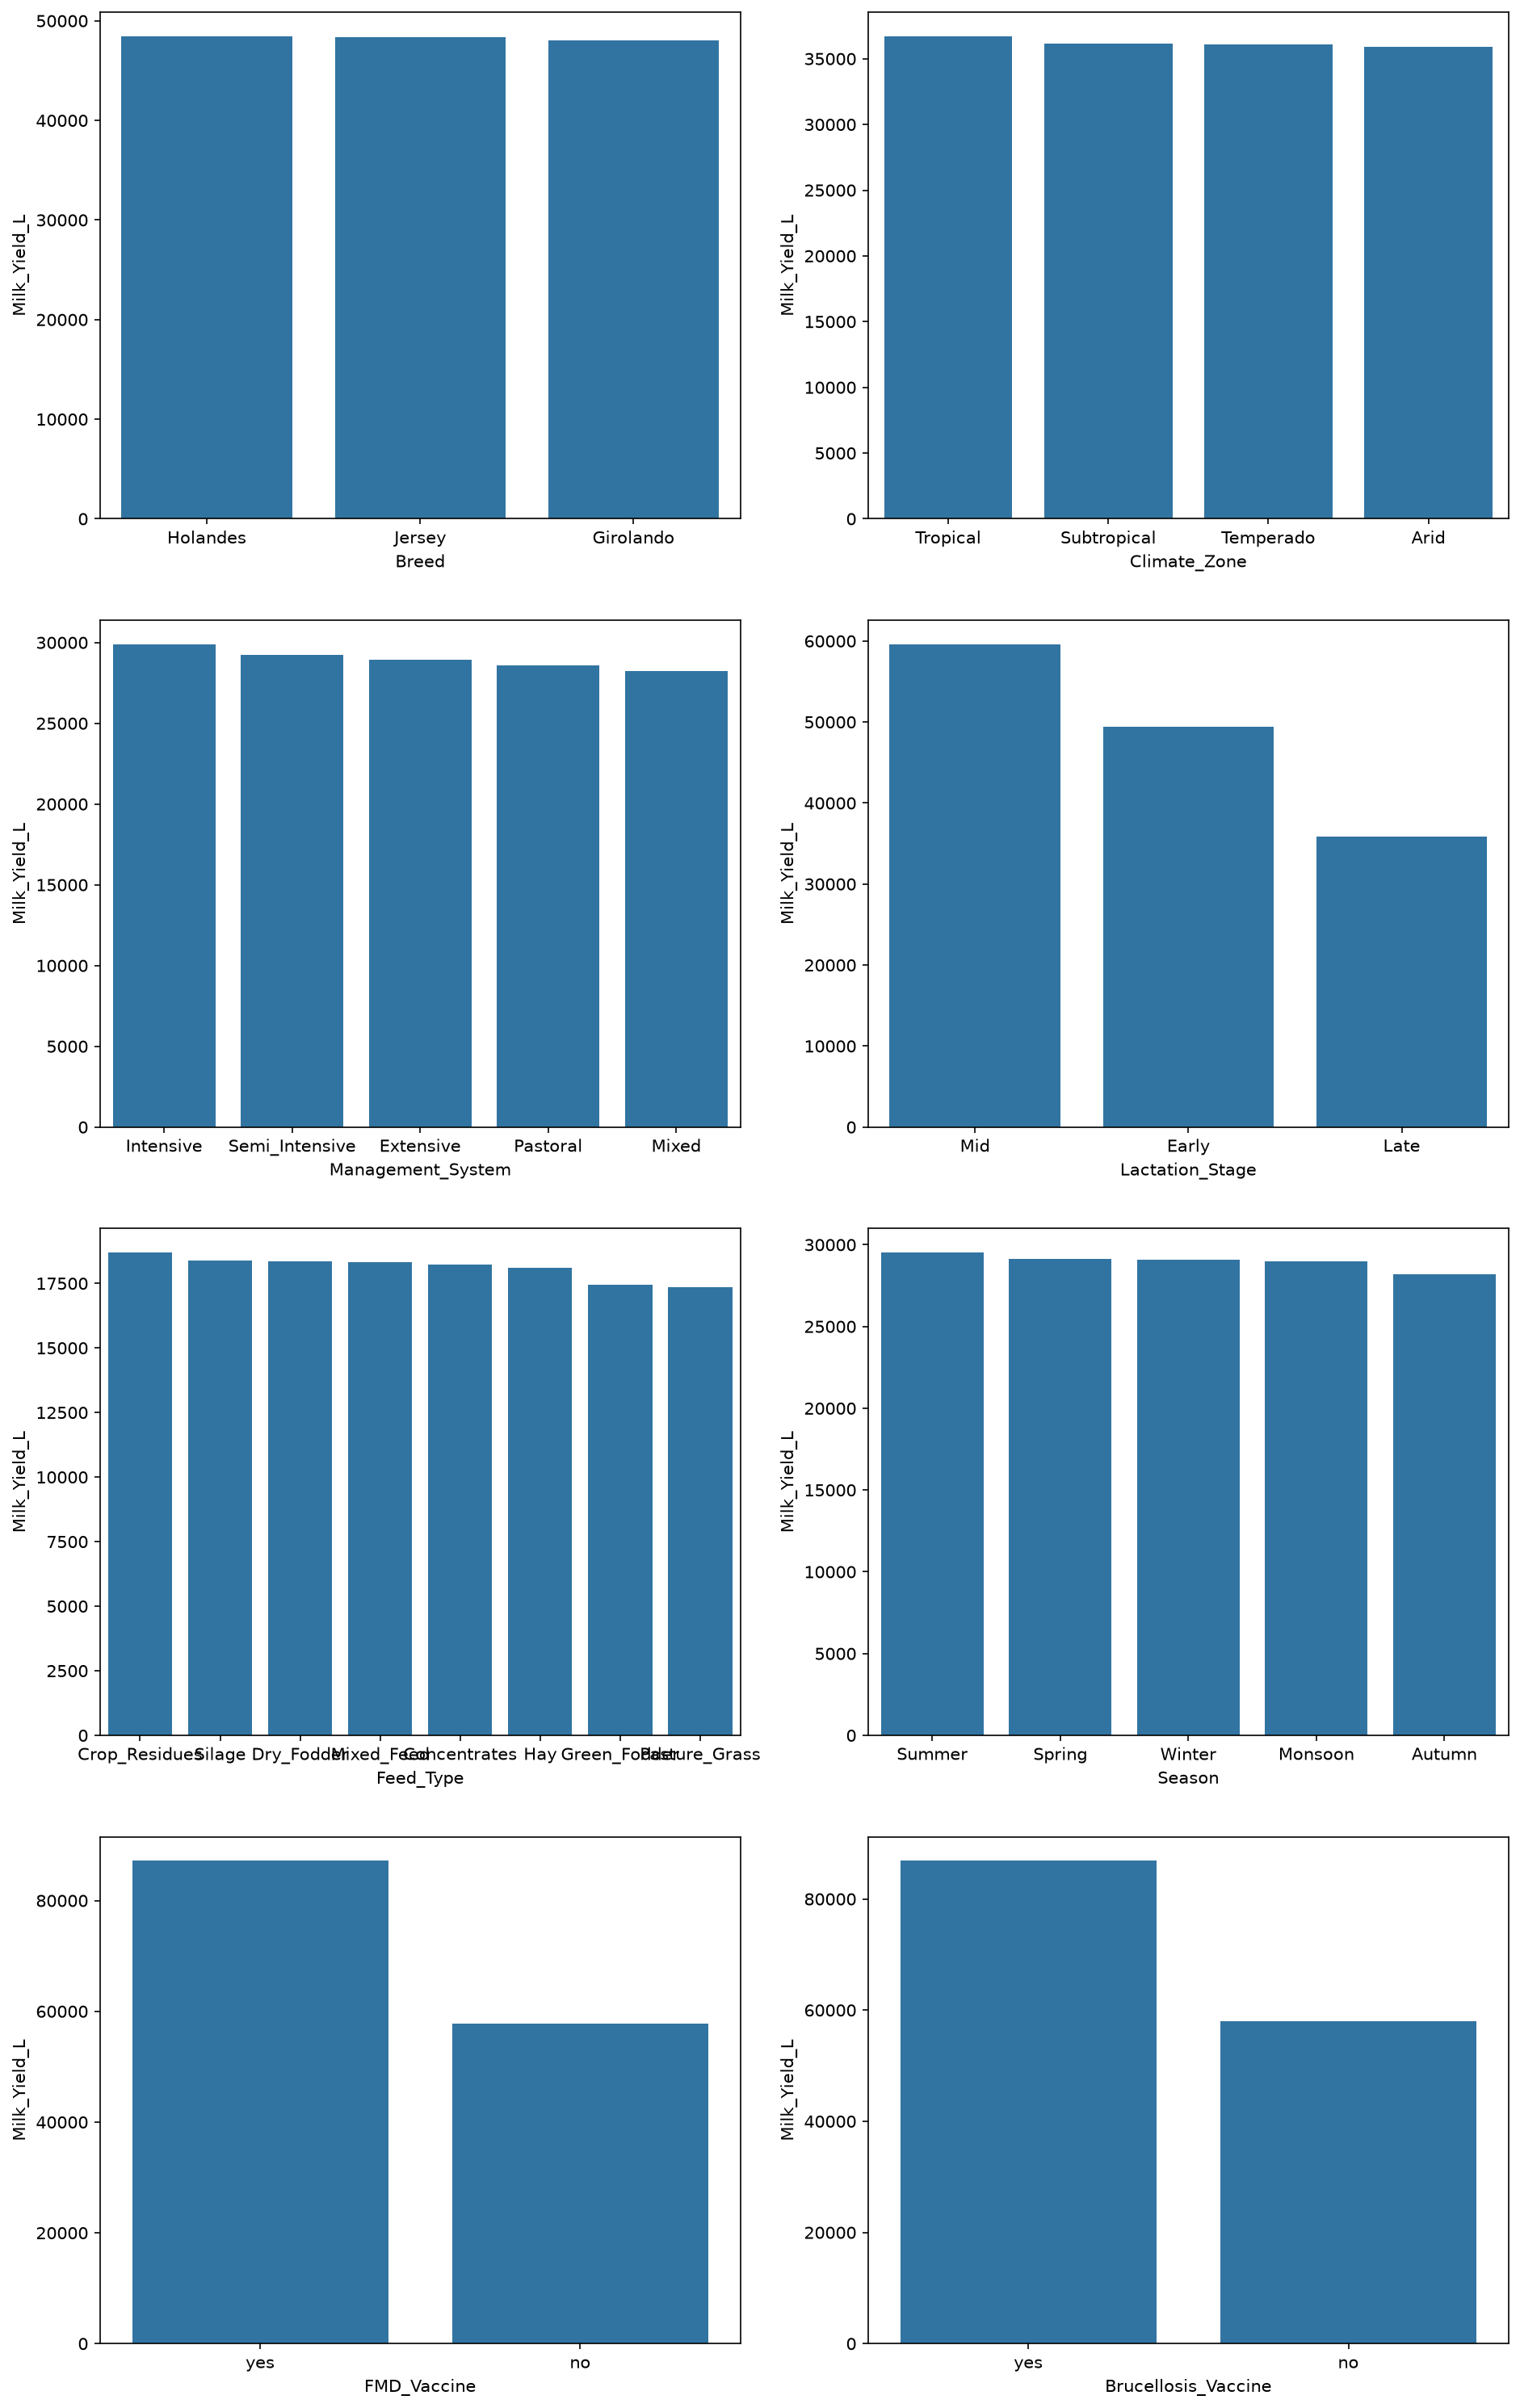

In [ ]:
# l1 = df1.loc[:, ['Breed', 'Milk_Yield_L']].groupby('Breed').sum().sort_values(by='Milk_Yield_L', ascending=False).reset_index()

columns = ['Breed', 'Climate_Zone', 'Management_System',
       'Lactation_Stage', 'Feed_Type', 'Season', 'FMD_Vaccine',
       'Brucellosis_Vaccine']

plt.figure(figsize=(15, 25), dpi=150)


for i, coluna in enumerate(columns):
    plt.subplot(4, 2, i+1)

    aux = df1.loc[:, [coluna, 'Milk_Yield_L']].groupby(coluna).sum().sort_values(by='Milk_Yield_L', ascending=False).reset_index()

    sns.barplot(data=aux, x=coluna, y='Milk_Yield_L')

In [14]:
df1.loc[:, ['Farm_ID', 'Date', 'Milk_Yield_L']].groupby(['Farm_ID', 'Date']).count().sort_values(by='Milk_Yield_L', ascending=False).reset_index()

,Farm_ID,Date,Milk_Yield_L
0,FARM_0993,2024-05-01,2
1,FARM_0958,2022-09-30,2
2,FARM_0121,2023-06-30,2
3,FARM_0920,2022-06-29,2
4,FARM_0563,2022-10-04,2
...,...,...,...
16405,FARM_0342,2023-07-23,1
16406,FARM_0342,2023-08-18,1
16407,FARM_0342,2023-09-21,1
16408,FARM_0342,2023-11-24,1


# Hipóteses

1. Raça Holandês tem maior produtividade diárias de leite do que demais raças
2. Clima temperado tem maior produtividade diárias de leite do que demais climas
3. Sistema intensivo tem maior produtividade diárias de leite do que demais sistemas
4. Vacas com estágio de lactação médio tem maior produtividade diários que vacas com estágio cedo e tardio
5. Vacas com alimentação com silagem tem maior produtivadde diários que as demais alimentação
6. Vacas que ingerem mais águas produzem mais litros leite diários
7. Vacas que andam mais, produzem menos litros de leite diários
8. Vacas que descansam mais tem mais produtividade litros de leite diários
9. Vacas que pastam mais horas produzem menos litros de leite diariamente
10. Vacas no outono produzem mais litros de leite diariamente
11. Estruturas com Housing_Score acimas de 0.5 produzem mais litros de leite diário
12. Vacas vacinadas produzem mais litros de leite diariamente
13. Na maior parte das vezes vacas com média diária da semana anterior com maiores produtividades, tendem a produzir maior litros de leite
14. Vacas com score corporal 3 tendem a ter maior produtividade diária
15. Vacas com intervalo de ordenha de 8h tendem a ter maior produtividade diária 

# E.D.A 

### Análise Univariada

#### Variável Resposta

<Axes: xlabel='Milk_Yield_L', ylabel='Count'>

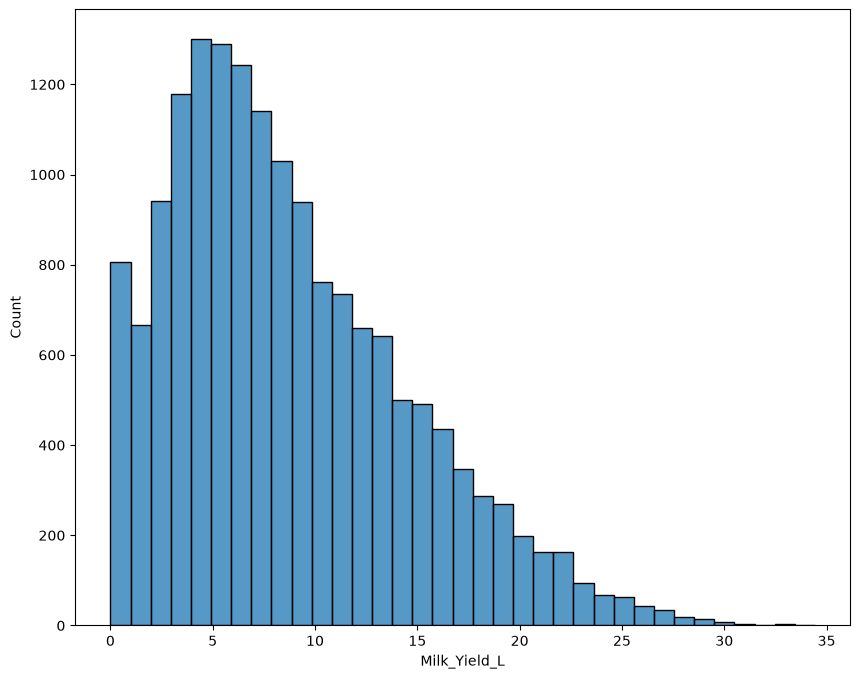

In [15]:
#estudo da variável resposta espsota que é variável contínua

plt.figure(figsize=(10,8))

#gráfico que plota a variável respsota
sns.histplot(df1['Milk_Yield_L'], bins=35)




#### Variáveis Numéricas

array([[<Axes: title={'center': 'index'}>,
        <Axes: title={'center': 'Age_Months'}>,
        <Axes: title={'center': 'Weight_kg'}>,
        <Axes: title={'center': 'Parity'}>],
       [<Axes: title={'center': 'Days_in_Milk'}>,
        <Axes: title={'center': 'Feed_Quantity_kg'}>,
        <Axes: title={'center': 'Feeding_Frequency'}>,
        <Axes: title={'center': 'Water_Intake_L'}>],
       [<Axes: title={'center': 'Walking_Distance_km'}>,
        <Axes: title={'center': 'Grazing_Duration_hrs'}>,
        <Axes: title={'center': 'Rumination_Time_hrs'}>,
        <Axes: title={'center': 'Resting_Hours'}>],
       [<Axes: title={'center': 'Ambient_Temperature_C'}>,
        <Axes: title={'center': 'Humidity_percent'}>,
        <Axes: title={'center': 'Housing_Score'}>,
        <Axes: title={'center': 'Previous_Week_Avg_Yield'}>],
       [<Axes: title={'center': 'Body_Condition_Score'}>,
        <Axes: title={'center': 'Milking_Interval_hrs'}>,
        <Axes: title={'center': 'Milk_Y

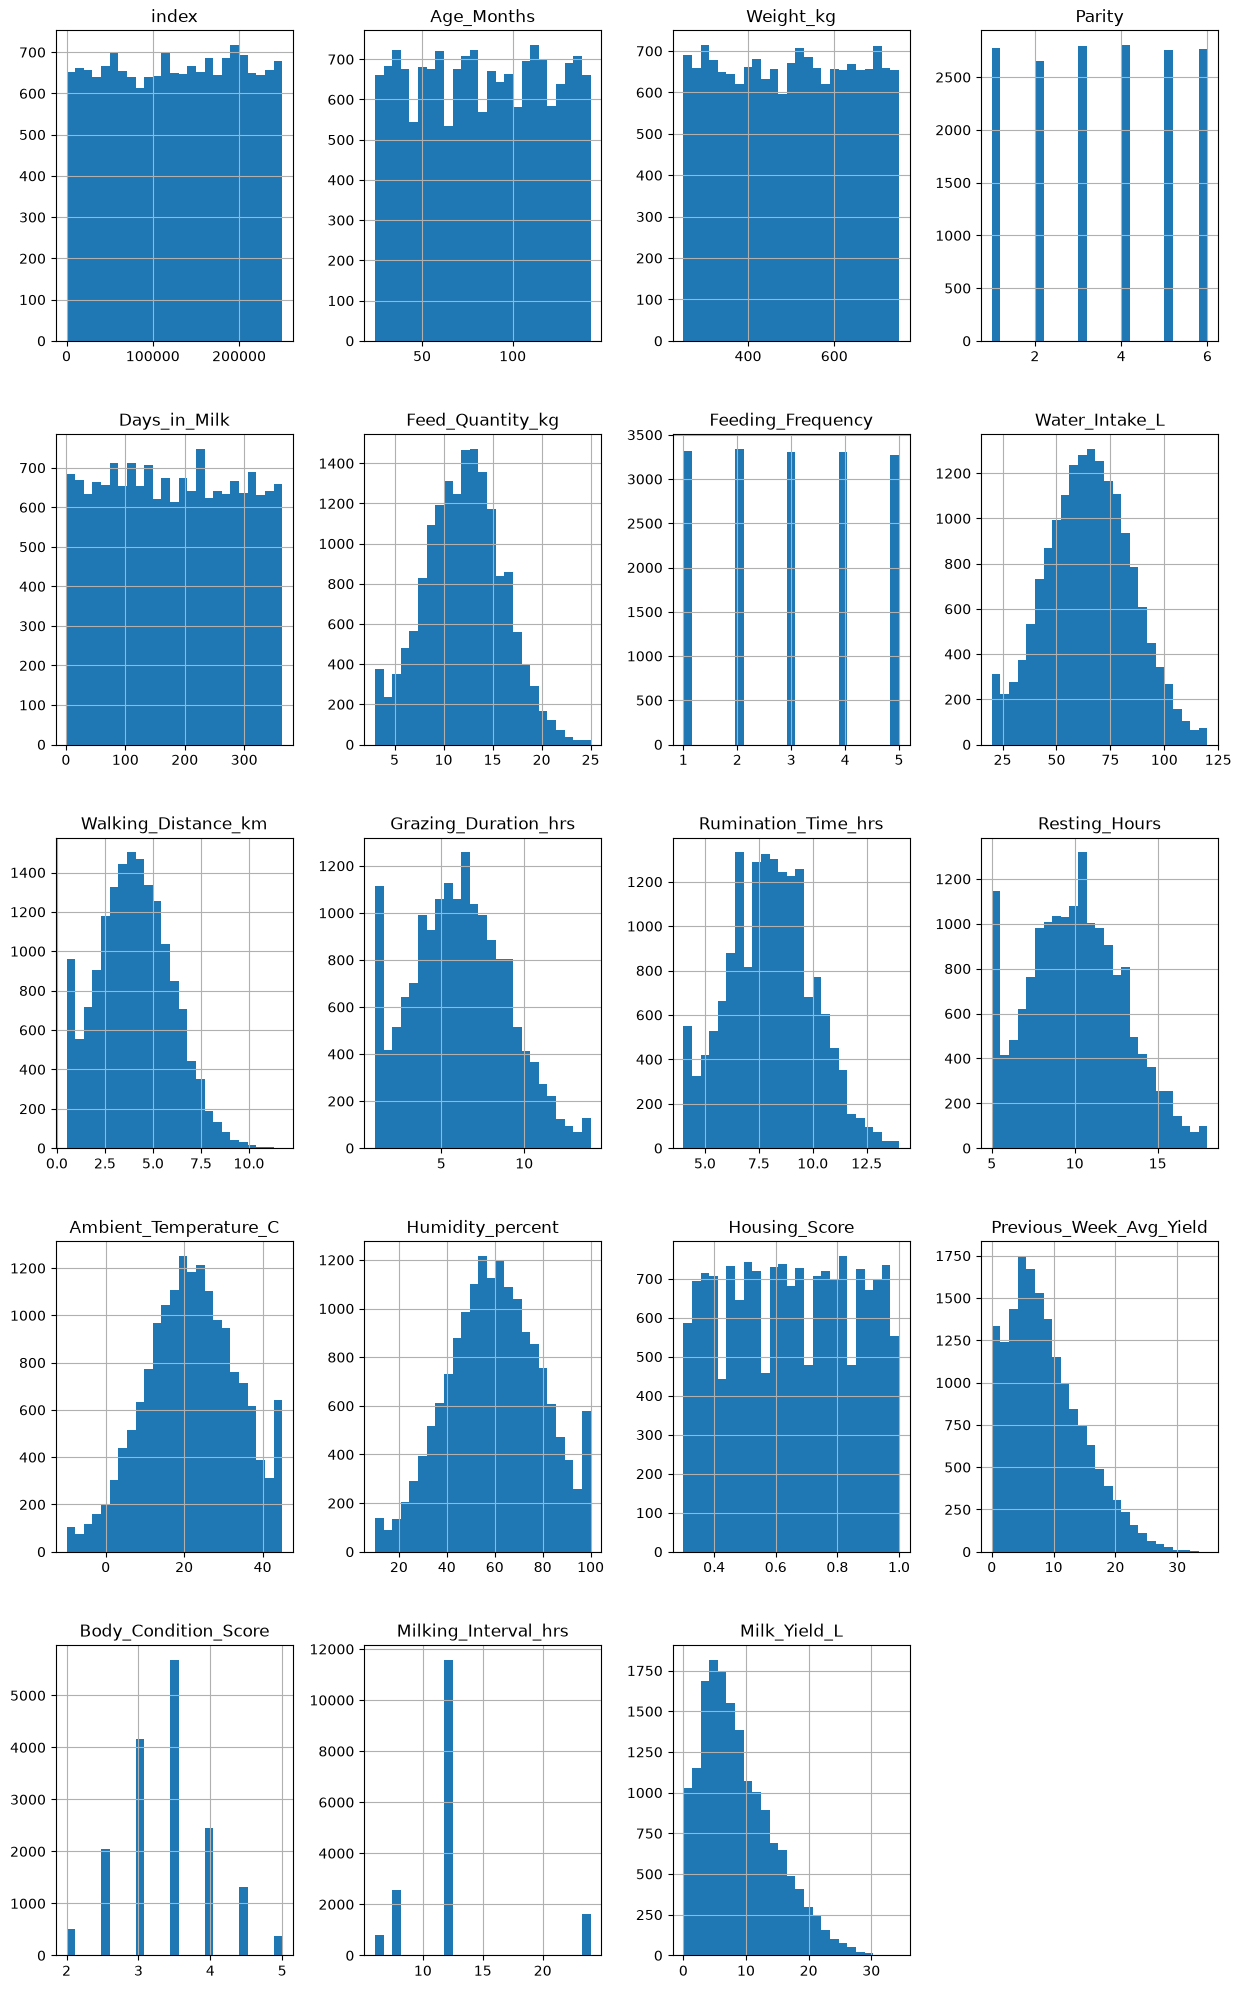

In [16]:
num_atributos.hist(bins = 25, figsize=(15,25))

#### Variáveis Categóricas

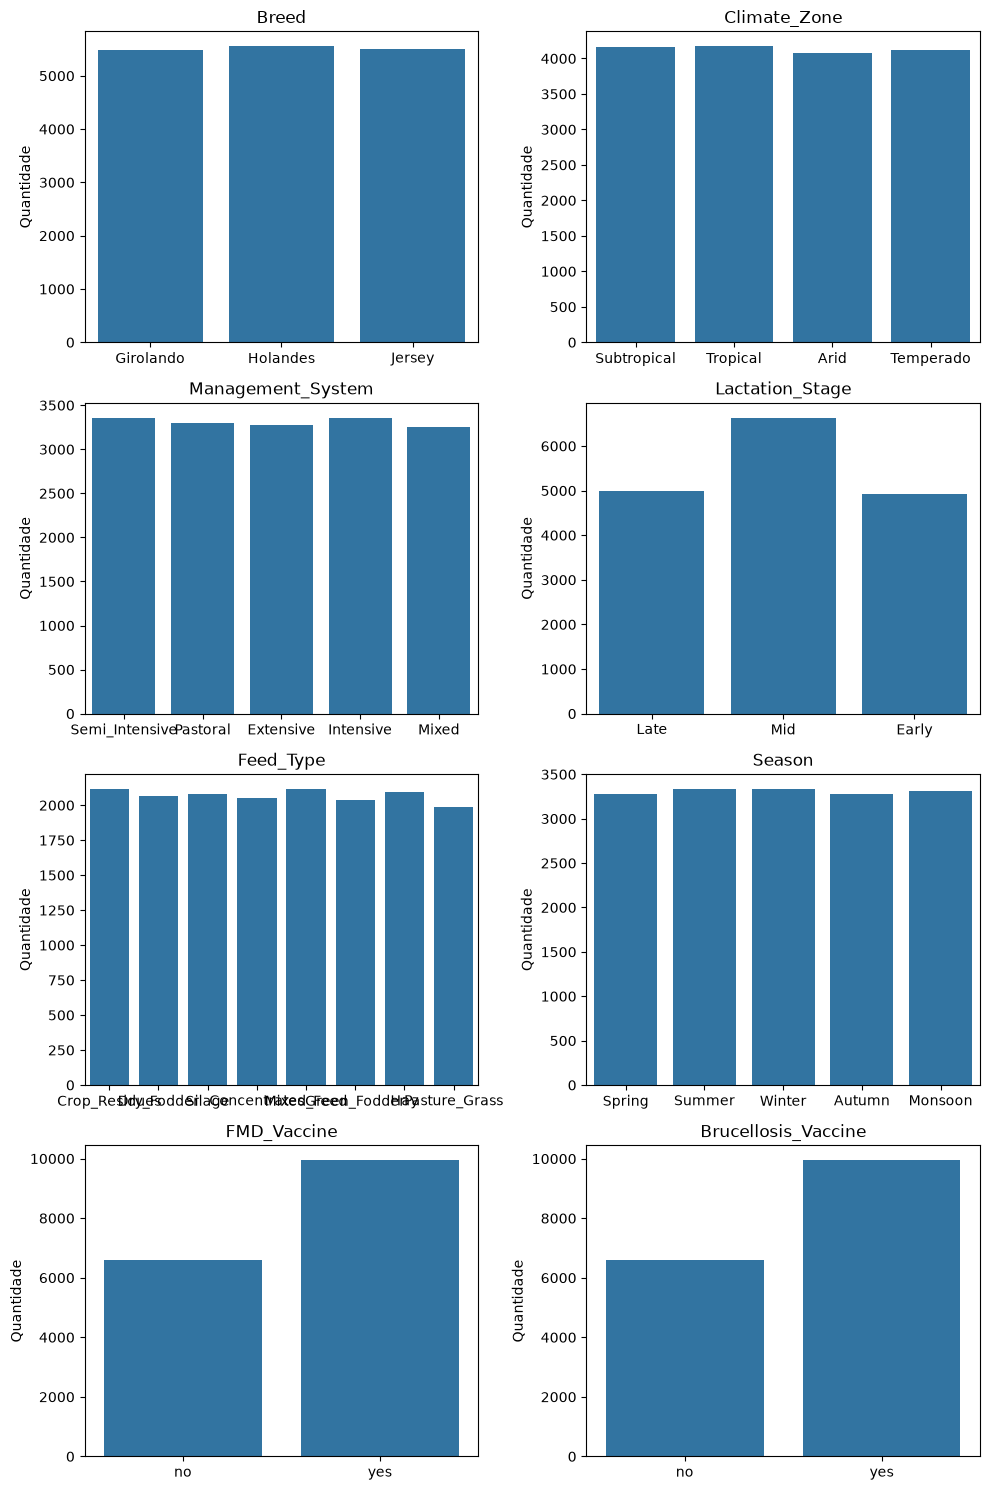

In [17]:
columns = ['Breed', 'Climate_Zone', 'Management_System',
       'Lactation_Stage', 'Feed_Type', 'Season', 'FMD_Vaccine',
       'Brucellosis_Vaccine']

fig, axes = plt.subplots(4, 2, figsize = (10, 15))

for ax, columns in zip(axes.flat, columns):
    sns.countplot(data = cat_atributos, x = columns, ax = ax)
    ax.set_title(columns)
    ax.set_xlabel('')
    ax.set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

### Análise Bivariada

<Axes: xlabel='Breed', ylabel='Milk_Yield_L'>

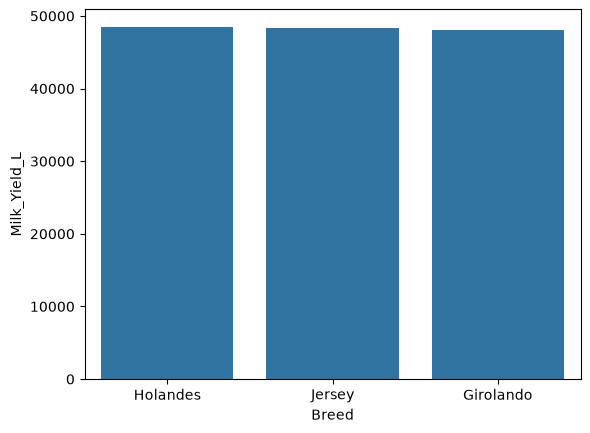

In [18]:
#1. Raça Holandês tem maior produtividade diárias de leite do que demais raças

aux = df1.loc[:, ['Breed', 'Milk_Yield_L']].groupby('Breed').sum().sort_values(by='Milk_Yield_L', ascending=False).reset_index()
aux

sns.barplot(data=aux, x='Breed', y='Milk_Yield_L')

<Axes: xlabel='Climate_Zone', ylabel='Milk_Yield_L'>

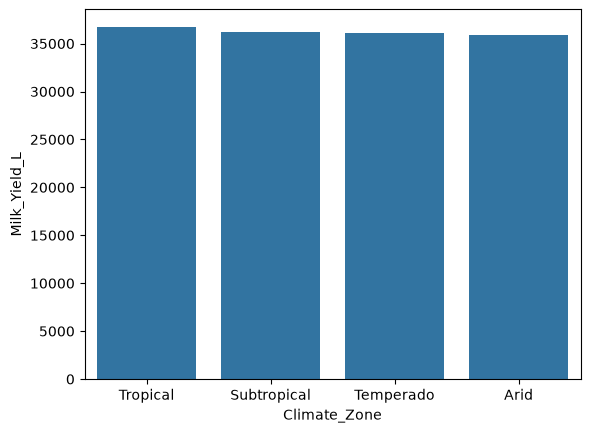

In [19]:
#2. Clima temperado tem maior produtividade diárias de leite do que demais climas

aux = df1.loc[:, ['Climate_Zone', 'Milk_Yield_L']].groupby('Climate_Zone').sum().sort_values(by='Milk_Yield_L', ascending=False).reset_index()
aux

sns.barplot(data=aux, x='Climate_Zone', y='Milk_Yield_L')

<Axes: xlabel='Management_System', ylabel='Milk_Yield_L'>

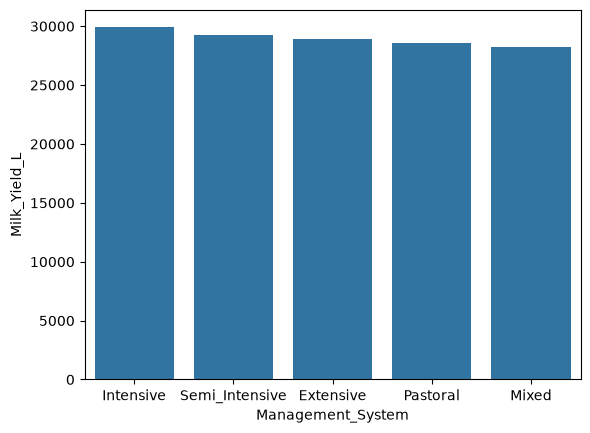

In [20]:
#3. Sistema intensivo tem maior produtividade diárias de leite do que demais sistemas

aux = df1.loc[:, ['Management_System', 'Milk_Yield_L']].groupby('Management_System').sum().sort_values(by='Milk_Yield_L', ascending=False).reset_index()
aux

sns.barplot(data=aux, x='Management_System', y='Milk_Yield_L')

<Axes: xlabel='Lactation_Stage', ylabel='Milk_Yield_L'>

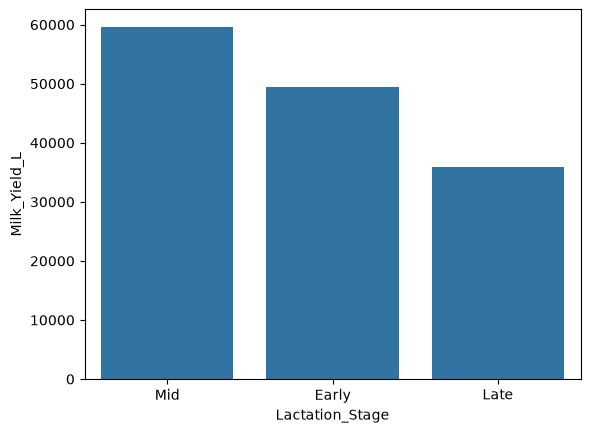

In [21]:
# 4. Vacas com estágio de lactação médio tem maior produtividade diários que vacas com estágio cedo e tardio

aux = df1.loc[:, ['Lactation_Stage', 'Milk_Yield_L']].groupby('Lactation_Stage').sum().sort_values(by='Milk_Yield_L', ascending=False).reset_index()
aux

sns.barplot(data=aux, x='Lactation_Stage', y='Milk_Yield_L')

<Axes: xlabel='Feed_Type', ylabel='Milk_Yield_L'>

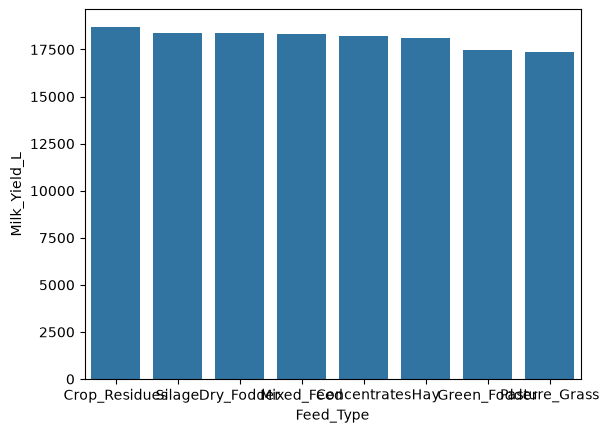

In [22]:
# 5. Vacas com alimentação com silagem tem maior produtivadde diários que as demais alimentação

aux = df1.loc[:, ['Feed_Type', 'Milk_Yield_L']].groupby('Feed_Type').sum().sort_values(by='Milk_Yield_L', ascending=False).reset_index()
aux

sns.barplot(data=aux, x='Feed_Type', y='Milk_Yield_L')

<Axes: xlabel='Water_Intake_L', ylabel='Milk_Yield_L'>

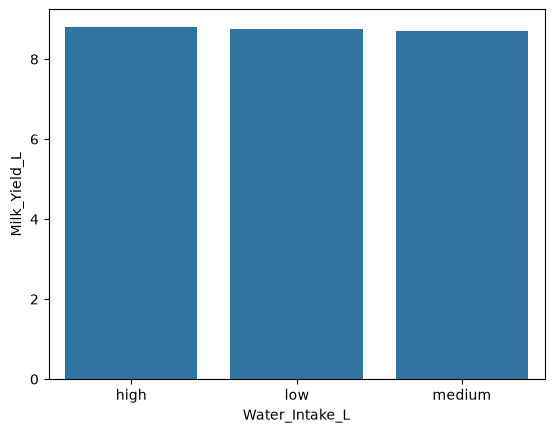

In [23]:
# 6. Vacas que ingerem mais águas produzem mais litros leite diários
df2 = df1.copy()
df2['Water_Intake_L'] = df2['Water_Intake_L'].apply(lambda x: 'low' if 15 <= x < 35 else ('medium' if 35 <= x < 65 else 'high'))
df2

aux = df2.loc[:, ['Water_Intake_L', 'Milk_Yield_L']].groupby('Water_Intake_L').mean().sort_values(by='Milk_Yield_L', ascending=False).reset_index()
aux

sns.barplot(data=aux, x='Water_Intake_L', y='Milk_Yield_L')

<Axes: xlabel='Water_Intake_L', ylabel='Cattle_ID'>

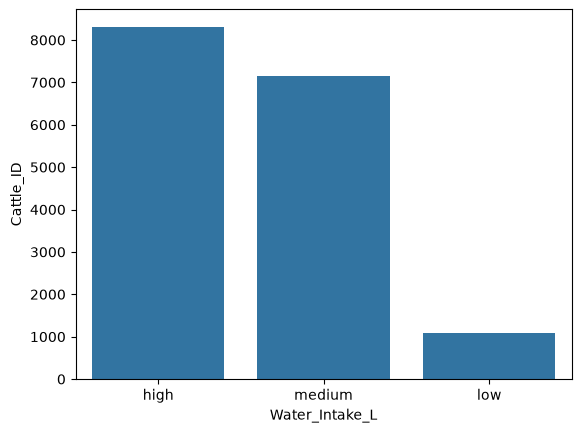

In [24]:
aux = df2.loc[:, ['Water_Intake_L', 'Cattle_ID']].groupby('Water_Intake_L').count().sort_values(by='Cattle_ID', ascending=False).reset_index()
aux

sns.barplot(data=aux, x='Water_Intake_L', y='Cattle_ID')

In [25]:
df1[['Water_Intake_L', 'Milk_Yield_L']].corr()

,Water_Intake_L,Milk_Yield_L
Water_Intake_L,1.000000,0.010085
Milk_Yield_L,0.010085,1.000000


55       11.73
7892     11.46
7738     11.15
14088    10.88
5088     10.86
         ...  
8137      0.50
7142      0.50
15076     0.50
15021     0.50
2135      0.50
Name: Walking_Distance_km, Length: 16541, dtype: float64

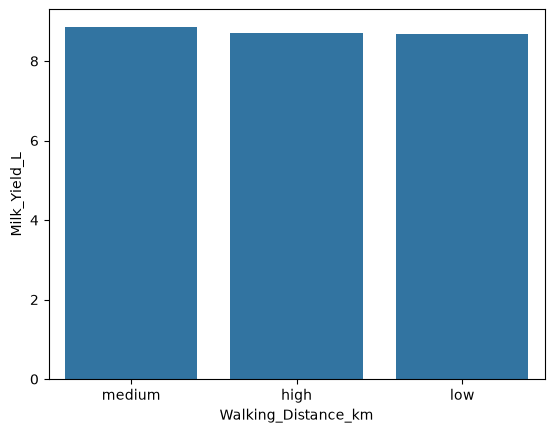

In [26]:
# 7. Vacas que andam mais, produzem menos litros de leite diários

df2['Walking_Distance_km'] = df2['Walking_Distance_km'].apply(lambda x: 'low' if 0 <= x < 2 else ('medium' if 2 <= x < 4 else 'high'))
df2
aux = df2.loc[:, ['Walking_Distance_km', 'Milk_Yield_L']].groupby('Walking_Distance_km').mean().sort_values(by='Milk_Yield_L', ascending=False).reset_index()
aux

sns.barplot(data=aux, x='Walking_Distance_km', y='Milk_Yield_L')


df1['Walking_Distance_km'].sort_values(ascending=False)

<Axes: xlabel='Walking_Distance_km', ylabel='Cattle_ID'>

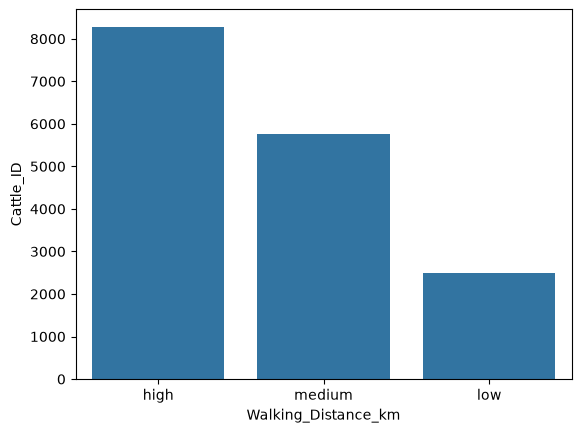

In [27]:
aux = df2.loc[:, ['Walking_Distance_km', 'Cattle_ID']].groupby('Walking_Distance_km').count().sort_values(by='Cattle_ID', ascending=False).reset_index()
aux

sns.barplot(data=aux, x='Walking_Distance_km', y='Cattle_ID')

,Resting_Hours,Milk_Yield_L
Resting_Hours,1.000000,0.003884
Milk_Yield_L,0.003884,1.000000


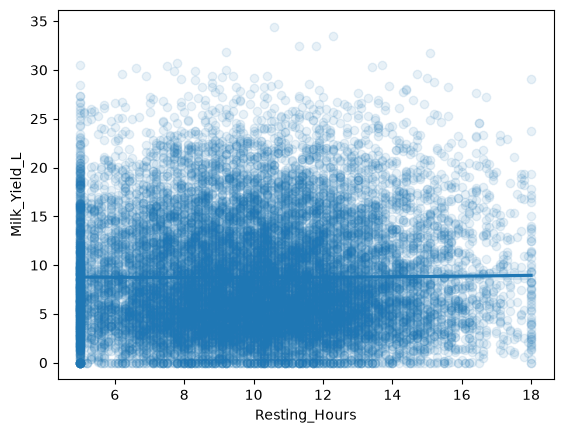

In [28]:
# 8. Vacas que descansam mais tem mais produtividade litros de leite diários

sns.regplot(data=df2, x='Resting_Hours', y='Milk_Yield_L', order=2, scatter_kws={'alpha': 0.1})

df2[['Resting_Hours', 'Milk_Yield_L']].corr()

<Axes: xlabel='Grazing_Duration_hrs', ylabel='Milk_Yield_L'>

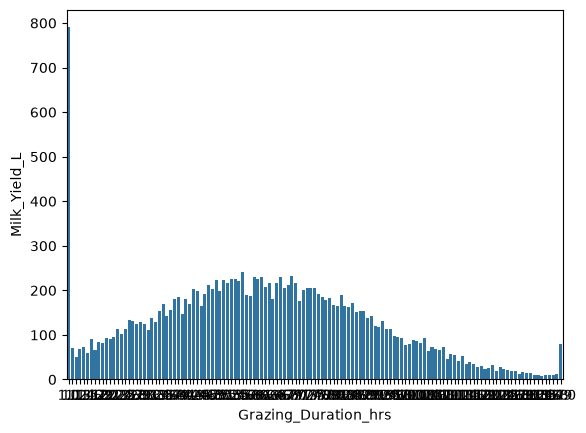

In [33]:
# 9. Vacas que pastam mais horas produzem menos litros de leite diariamente

aux = df2.loc[:, ['Grazing_Duration_hrs', 'Milk_Yield_L']].groupby('Grazing_Duration_hrs').count().sort_values(by='Milk_Yield_L', ascending=False).reset_index()
aux

sns.barplot(data=aux, x='Grazing_Duration_hrs', y='Milk_Yield_L')

<Axes: xlabel='Season', ylabel='Milk_Yield_L'>

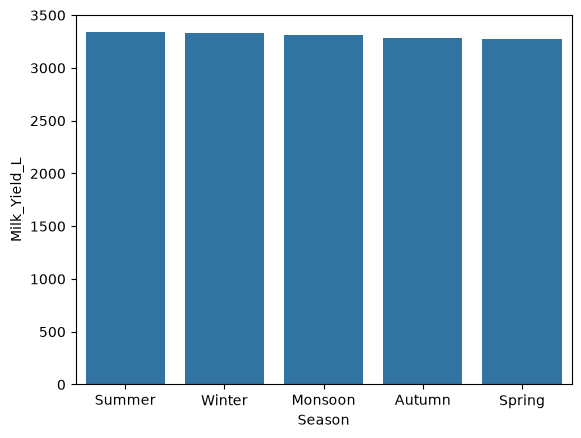

In [34]:
# 10. Vacas no outono produzem mais litros de leite diariamente

aux = df2.loc[:, ['Season', 'Milk_Yield_L']].groupby('Season').count().sort_values(by='Milk_Yield_L', ascending=False).reset_index()
aux

sns.barplot(data=aux, x='Season', y='Milk_Yield_L')


<Axes: xlabel='Housing_Score', ylabel='Milk_Yield_L'>

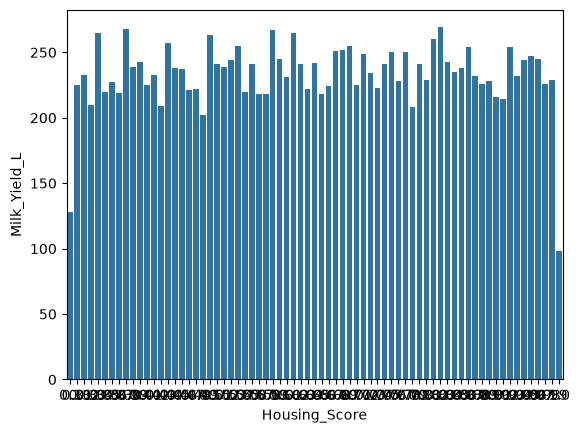

In [35]:
# 11. Estruturas com Housing_Score acimas de 0.5 produzem mais litros de leite diário

aux = df2.loc[:, ['Housing_Score', 'Milk_Yield_L']].groupby('Housing_Score').count().sort_values(by='Milk_Yield_L', ascending=False).reset_index()
aux

sns.barplot(data=aux, x='Housing_Score', y='Milk_Yield_L')

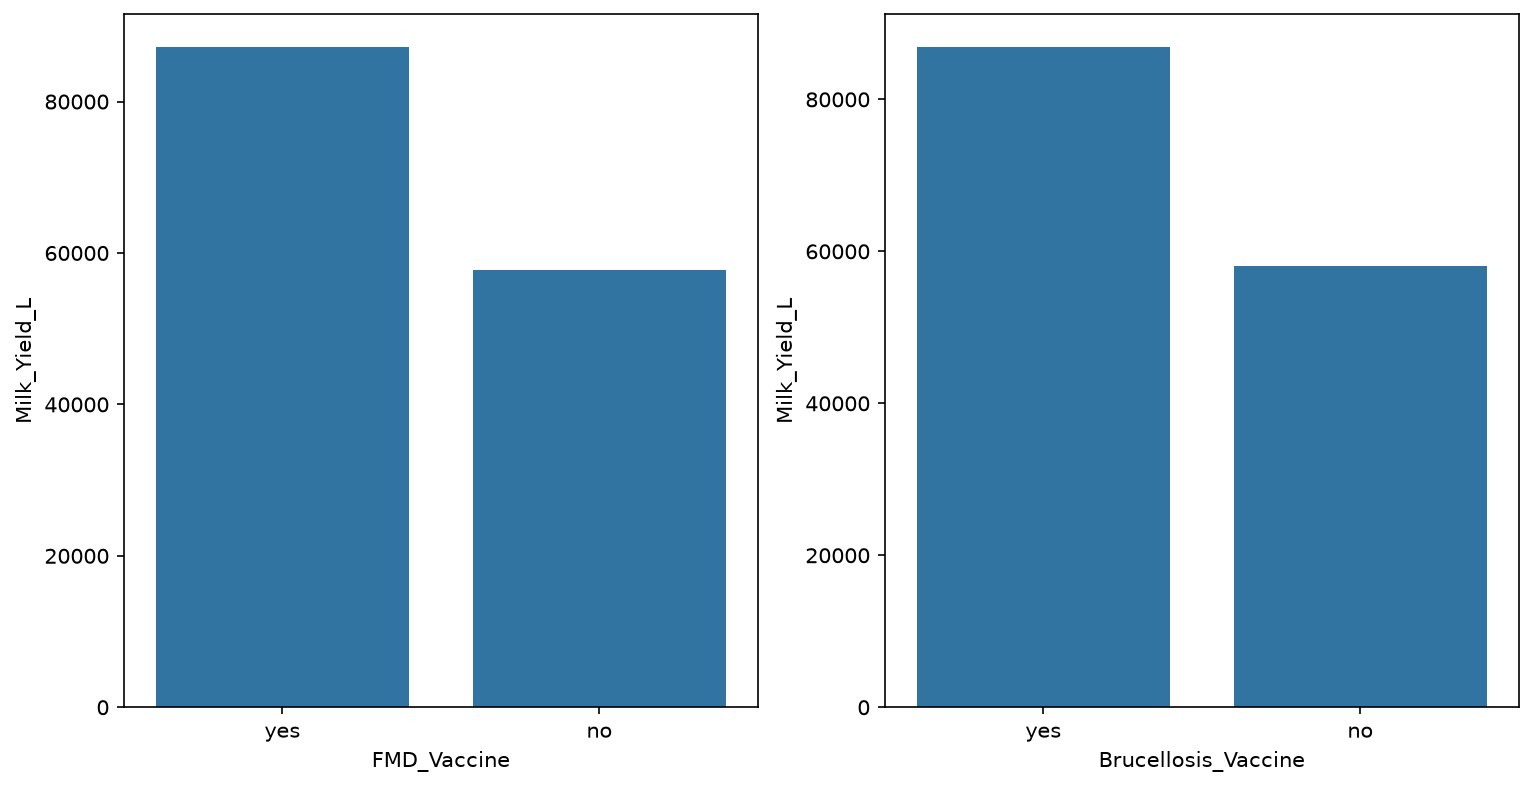

In [40]:
# 12. Vacas vacinadas produzem mais litros de leite diariamente

columns = ['FMD_Vaccine',
       'Brucellosis_Vaccine']

plt.figure(figsize=(12, 6), dpi=150)


for i, coluna in enumerate(columns):
    plt.subplot(1, 2, i+1)

    aux = df1.loc[:, [coluna, 'Milk_Yield_L']].groupby(coluna).sum().sort_values(by='Milk_Yield_L', ascending=False).reset_index()

    sns.barplot(data=aux, x=coluna, y='Milk_Yield_L')

,Previous_Week_Avg_Yield,Milk_Yield_L
Previous_Week_Avg_Yield,1.000000,0.969408
Milk_Yield_L,0.969408,1.000000


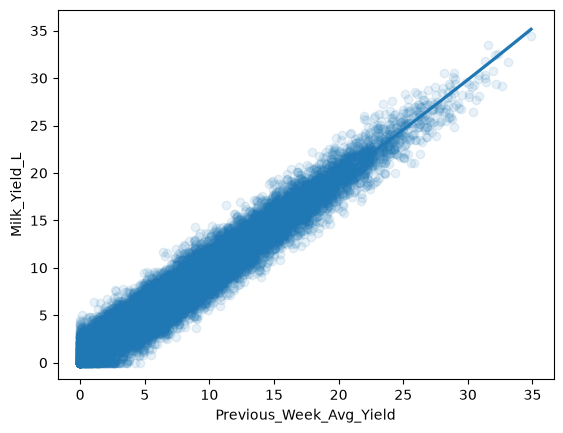

In [42]:
# 13. Na maior parte das vezes vacas com média diária da semana anterior com maiores produtividades, tendem a produzir maior litros de leite

sns.regplot(data=df2, x='Previous_Week_Avg_Yield', y='Milk_Yield_L', order=2, scatter_kws={'alpha': 0.1})

df2[['Previous_Week_Avg_Yield', 'Milk_Yield_L']].corr()

<Axes: xlabel='Body_Condition_Score', ylabel='Milk_Yield_L'>

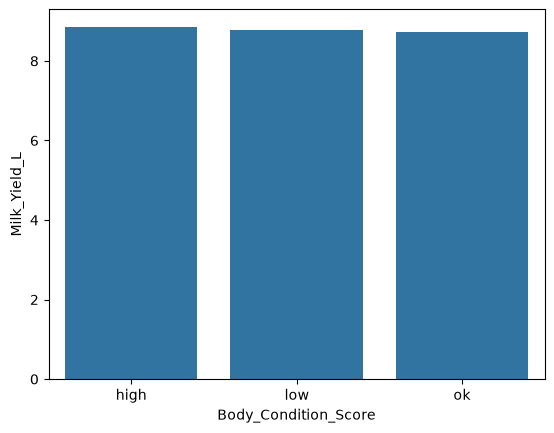

In [43]:
# 14. Vacas com score corporal 3 tendem a ter maior produtividade diária

df2['Body_Condition_Score'] = df2['Body_Condition_Score'].apply(lambda x: 'low' if 0 <= x < 3 else ('ok' if 3 <= x < 4 else 'high'))
df2
aux = df2.loc[:, ['Body_Condition_Score', 'Milk_Yield_L']].groupby('Body_Condition_Score').mean().sort_values(by='Milk_Yield_L', ascending=False).reset_index()
aux

sns.barplot(data=aux, x='Body_Condition_Score', y='Milk_Yield_L')


<Axes: xlabel='Milking_Interval_hrs', ylabel='Milk_Yield_L'>

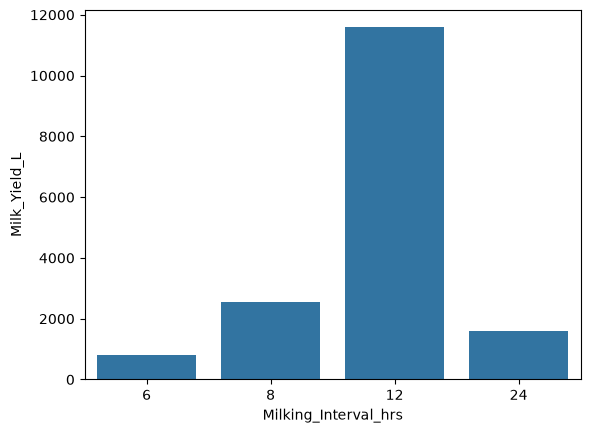

In [44]:
# 15. Vacas com intervalo de ordenha de 8h tendem a ter maior produtividade diária 

aux = df2.loc[:, ['Milking_Interval_hrs', 'Milk_Yield_L']].groupby('Milking_Interval_hrs').count().sort_values(by='Milk_Yield_L', ascending=False).reset_index()
aux

sns.barplot(data=aux, x='Milking_Interval_hrs', y='Milk_Yield_L')

In [51]:
df1.columns

df2.to_csv('dataset_leite_csv.csv', index=False)

df2.head().T

,0,1,2,3,4
index,3,14,51,73,77
Cattle_ID,CATTLE_000004,CATTLE_000015,CATTLE_000052,CATTLE_000074,CATTLE_000078
Breed,Girolando,Holandes,Holandes,Jersey,Girolando
Country,BR,BR,BR,BR,BR
Climate_Zone,Subtropical,Tropical,Arid,Tropical,Tropical
Management_System,Semi_Intensive,Pastoral,Extensive,Intensive,Semi_Intensive
Age_Months,73,142,28,142,86
Weight_kg,260.5,532.3,401.0,332.6,620.6
Parity,5,2,5,6,1
Lactation_Stage,Late,Mid,Early,Mid,Early


### Análise Multivariada

#### Variáveis Numéricas

#### Variáveis Categóricas

# Preparação de Dados